In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("Indian_Kids_Screen_Time.csv")
df

,Age,Gender,Avg_Daily_Screen_Time_hr,Primary_Device,Exceeded_Recommended_Limit,Educational_to_Recreational_Ratio,Health_Impacts,Urban_or_Rural
0,14,Male,3.99,Smartphone,True,0.42,"Poor Sleep, Eye Strain",Urban
1,11,Female,4.61,Laptop,True,0.30,Poor Sleep,Urban
2,18,Female,3.73,TV,True,0.32,Poor Sleep,Urban
3,15,Female,1.21,Laptop,False,0.39,NaN,Urban
4,12,Female,5.89,Smartphone,True,0.49,"Poor Sleep, Anxiety",Urban
...,...,...,...,...,...,...,...,...
9707,17,Male,3.26,Smartphone,True,0.44,Poor Sleep,Urban
9708,17,Female,4.43,Smartphone,True,0.40,Poor Sleep,Rural
9709,16,Male,5.62,Smartphone,True,0.39,"Poor Sleep, Eye Strain, Anxiety",Rural
9710,17,Male,5.60,TV,True,0.43,Poor Sleep,Urban


In [3]:
df.head()

,Age,Gender,Avg_Daily_Screen_Time_hr,Primary_Device,Exceeded_Recommended_Limit,Educational_to_Recreational_Ratio,Health_Impacts,Urban_or_Rural
0,14,Male,3.99,Smartphone,True,0.42,"Poor Sleep, Eye Strain",Urban
1,11,Female,4.61,Laptop,True,0.30,Poor Sleep,Urban
2,18,Female,3.73,TV,True,0.32,Poor Sleep,Urban
3,15,Female,1.21,Laptop,False,0.39,NaN,Urban
4,12,Female,5.89,Smartphone,True,0.49,"Poor Sleep, Anxiety",Urban


In [4]:
df.tail()

,Age,Gender,Avg_Daily_Screen_Time_hr,Primary_Device,Exceeded_Recommended_Limit,Educational_to_Recreational_Ratio,Health_Impacts,Urban_or_Rural
9707,17,Male,3.26,Smartphone,True,0.44,Poor Sleep,Urban
9708,17,Female,4.43,Smartphone,True,0.40,Poor Sleep,Rural
9709,16,Male,5.62,Smartphone,True,0.39,"Poor Sleep, Eye Strain, Anxiety",Rural
9710,17,Male,5.60,TV,True,0.43,Poor Sleep,Urban
9711,15,Female,6.12,TV,True,0.33,Anxiety,Urban


In [5]:
df.isnull().sum() # Check if any column has missing values

Age                                     0
Gender                                  0
Avg_Daily_Screen_Time_hr                0
Primary_Device                          0
Exceeded_Recommended_Limit              0
Educational_to_Recreational_Ratio       0
Health_Impacts                       3218
Urban_or_Rural                          0
dtype: int64

In [6]:
df.info() # Get information about columns, data types, and non-null counts

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9712 entries, 0 to 9711
Data columns (total 8 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Age                                9712 non-null   int64  
 1   Gender                             9712 non-null   object 
 2   Avg_Daily_Screen_Time_hr           9712 non-null   float64
 3   Primary_Device                     9712 non-null   object 
 4   Exceeded_Recommended_Limit         9712 non-null   bool   
 5   Educational_to_Recreational_Ratio  9712 non-null   float64
 6   Health_Impacts                     6494 non-null   object 
 7   Urban_or_Rural                     9712 non-null   object 
dtypes: bool(1), float64(2), int64(1), object(4)
memory usage: 540.7+ KB


In [7]:
df.describe() # Display descriptive statistics for numerical columns

,Age,Avg_Daily_Screen_Time_hr,Educational_to_Recreational_Ratio
count,9712.000000,9712.000000,9712.000000
mean,12.979201,4.352837,0.427226
std,3.162437,1.718232,0.073221
min,8.000000,0.000000,0.300000
25%,10.000000,3.410000,0.370000
50%,13.000000,4.440000,0.430000
75%,16.000000,5.380000,0.480000
max,18.000000,13.890000,0.600000


In [8]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 44


In [9]:
df.shape

(9712, 8)

In [10]:
df.drop_duplicates(inplace=True)

In [11]:
df.duplicated().sum()

0

In [12]:
df.shape

(9668, 8)

In [13]:
df.columns

Index(['Age', 'Gender', 'Avg_Daily_Screen_Time_hr', 'Primary_Device',
       'Exceeded_Recommended_Limit', 'Educational_to_Recreational_Ratio',
       'Health_Impacts', 'Urban_or_Rural'],
      dtype='object')

In [14]:
df.columns.tolist()

['Age',
 'Gender',
 'Avg_Daily_Screen_Time_hr',
 'Primary_Device',
 'Exceeded_Recommended_Limit',
 'Educational_to_Recreational_Ratio',
 'Health_Impacts',
 'Urban_or_Rural']

In [15]:
df.dtypes

Age                                    int64
Gender                                object
Avg_Daily_Screen_Time_hr             float64
Primary_Device                        object
Exceeded_Recommended_Limit              bool
Educational_to_Recreational_Ratio    float64
Health_Impacts                        object
Urban_or_Rural                        object
dtype: object

In [16]:
df.Educational_to_Recreational_Ratio.unique()

array([0.42, 0.3 , 0.32, 0.39, 0.49, 0.44, 0.48, 0.54, 0.36, 0.43, 0.4 ,
       0.34, 0.33, 0.58, 0.5 , 0.51, 0.41, 0.47, 0.38, 0.35, 0.56, 0.46,
       0.59, 0.45, 0.53, 0.6 , 0.31, 0.57, 0.37, 0.52, 0.55])

In [17]:
df['Educational_to_Recreational_Ratio'].unique()

array([0.42, 0.3 , 0.32, 0.39, 0.49, 0.44, 0.48, 0.54, 0.36, 0.43, 0.4 ,
       0.34, 0.33, 0.58, 0.5 , 0.51, 0.41, 0.47, 0.38, 0.35, 0.56, 0.46,
       0.59, 0.45, 0.53, 0.6 , 0.31, 0.57, 0.37, 0.52, 0.55])

In [18]:
df[df['Age']>15]

,Age,Gender,Avg_Daily_Screen_Time_hr,Primary_Device,Exceeded_Recommended_Limit,Educational_to_Recreational_Ratio,Health_Impacts,Urban_or_Rural
2,18,Female,3.73,TV,True,0.32,Poor Sleep,Urban
6,17,Male,2.97,TV,False,0.48,NaN,Rural
9,18,Male,3.24,Tablet,True,0.48,"Poor Sleep, Obesity Risk",Urban
10,18,Male,3.53,Tablet,True,0.44,Poor Sleep,Rural
25,17,Male,4.96,Smartphone,True,0.32,NaN,Urban
...,...,...,...,...,...,...,...,...
9701,16,Male,6.08,Smartphone,True,0.38,NaN,Urban
9707,17,Male,3.26,Smartphone,True,0.44,Poor Sleep,Urban
9708,17,Female,4.43,Smartphone,True,0.40,Poor Sleep,Rural
9709,16,Male,5.62,Smartphone,True,0.39,"Poor Sleep, Eye Strain, Anxiety",Rural


In [19]:
df.sort_values('Age')

,Age,Gender,Avg_Daily_Screen_Time_hr,Primary_Device,Exceeded_Recommended_Limit,Educational_to_Recreational_Ratio,Health_Impacts,Urban_or_Rural
2224,8,Male,3.55,TV,True,0.42,NaN,Urban
6375,8,Male,7.65,Smartphone,True,0.40,"Poor Sleep, Eye Strain, Obesity Risk",Urban
763,8,Female,6.02,TV,True,0.44,NaN,Urban
1680,8,Female,5.72,TV,True,0.41,NaN,Urban
6183,8,Male,7.01,Smartphone,True,0.53,"Poor Sleep, Anxiety",Urban
...,...,...,...,...,...,...,...,...
8609,18,Male,4.78,Tablet,True,0.44,"Poor Sleep, Obesity Risk",Urban
4361,18,Female,5.38,Laptop,True,0.43,"Poor Sleep, Anxiety",Urban
4357,18,Female,3.08,Smartphone,True,0.48,Eye Strain,Rural
1530,18,Female,3.84,Laptop,True,0.43,NaN,Urban


In [20]:
df.sort_values("Age",ascending=False) #Descending order

,Age,Gender,Avg_Daily_Screen_Time_hr,Primary_Device,Exceeded_Recommended_Limit,Educational_to_Recreational_Ratio,Health_Impacts,Urban_or_Rural
6470,18,Male,3.75,Laptop,True,0.33,"Poor Sleep, Eye Strain, Obesity Risk",Urban
7835,18,Female,3.42,Smartphone,True,0.47,"Poor Sleep, Eye Strain",Rural
784,18,Male,5.26,Smartphone,True,0.36,"Poor Sleep, Obesity Risk",Urban
785,18,Female,5.02,Laptop,True,0.43,"Poor Sleep, Eye Strain, Anxiety",Urban
2100,18,Male,2.98,Laptop,False,0.36,NaN,Rural
...,...,...,...,...,...,...,...,...
8887,8,Male,3.07,Smartphone,True,0.57,NaN,Urban
7580,8,Male,7.83,TV,True,0.44,Poor Sleep,Urban
7577,8,Female,1.65,Smartphone,False,0.44,NaN,Urban
3363,8,Male,1.12,Tablet,False,0.45,NaN,Rural


In [21]:
df[df["Primary_Device"]=="TV"]

,Age,Gender,Avg_Daily_Screen_Time_hr,Primary_Device,Exceeded_Recommended_Limit,Educational_to_Recreational_Ratio,Health_Impacts,Urban_or_Rural
2,18,Female,3.73,TV,True,0.32,Poor Sleep,Urban
6,17,Male,2.97,TV,False,0.48,NaN,Rural
7,10,Male,2.74,TV,True,0.54,NaN,Urban
11,15,Female,4.94,TV,True,0.36,Poor Sleep,Rural
13,11,Male,6.08,TV,True,0.48,Eye Strain,Rural
...,...,...,...,...,...,...,...,...
9699,10,Female,2.85,TV,True,0.49,NaN,Urban
9704,8,Female,4.23,TV,True,0.51,Eye Strain,Urban
9705,9,Female,8.07,TV,True,0.53,"Poor Sleep, Anxiety, Obesity Risk",Urban
9710,17,Male,5.60,TV,True,0.43,Poor Sleep,Urban


In [22]:
#Helpful to remove the extra spaces and Case differences → "male", "MALE", "Male"
df["Gender"] = df["Gender"].str.strip().str.title()
df["Primary_Device"] = df["Primary_Device"].str.strip().str.title()
df["Urban_or_Rural"] = df["Urban_or_Rural"].str.strip().str.title()

In [23]:
df["Health_Impacts"] = df["Health_Impacts"].fillna("None") #this will fill it with none values

In [24]:
#pd.cut() divides the age range into bins (intervals) and we creating a new column Age Group
#Here 8-12 -> Child and 12-18 Teen 
df["Age_Group"] = pd.cut(
    df["Age"],
    bins=[8,12, 18],
    labels=["Child", "Teen"]
)

In [25]:
df

,Age,Gender,Avg_Daily_Screen_Time_hr,Primary_Device,Exceeded_Recommended_Limit,Educational_to_Recreational_Ratio,Health_Impacts,Urban_or_Rural,Age_Group
0,14,Male,3.99,Smartphone,True,0.42,"Poor Sleep, Eye Strain",Urban,Teen
1,11,Female,4.61,Laptop,True,0.30,Poor Sleep,Urban,Child
2,18,Female,3.73,Tv,True,0.32,Poor Sleep,Urban,Teen
3,15,Female,1.21,Laptop,False,0.39,None,Urban,Teen
4,12,Female,5.89,Smartphone,True,0.49,"Poor Sleep, Anxiety",Urban,Child
...,...,...,...,...,...,...,...,...,...
9707,17,Male,3.26,Smartphone,True,0.44,Poor Sleep,Urban,Teen
9708,17,Female,4.43,Smartphone,True,0.40,Poor Sleep,Rural,Teen
9709,16,Male,5.62,Smartphone,True,0.39,"Poor Sleep, Eye Strain, Anxiety",Rural,Teen
9710,17,Male,5.60,Tv,True,0.43,Poor Sleep,Urban,Teen


In [26]:
##EXPLORATORY DATA ANALYSIS (EDA) 
##Visualization

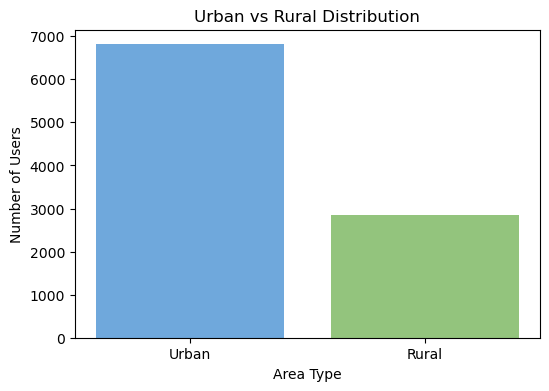

In [27]:
#Urban vs Rural Users
area_counts = df["Urban_or_Rural"].value_counts()
plt.figure(figsize=(6,4))
plt.bar(area_counts.index, area_counts.values, color=['#6fa8dc','#93c47d'])
plt.title("Urban vs Rural Distribution")
plt.xlabel("Area Type")
plt.ylabel("Number of Users")
plt.show()

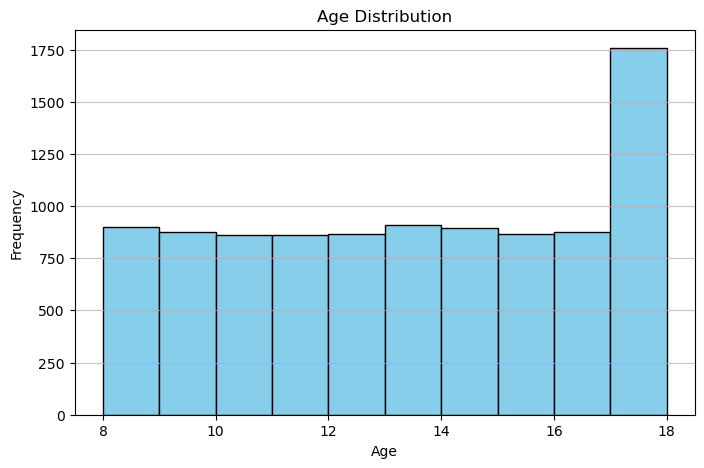

In [28]:
#Age Distribution - histogram
plt.figure(figsize=(8,5))
plt.hist(df["Age"], color='skyblue', edgecolor='black')
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.grid(axis='y', alpha=0.75)
plt.show()


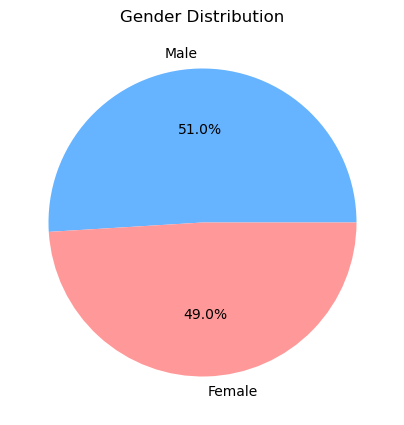

In [29]:
#Gender Distribution
gender_counts = df["Gender"].value_counts()
plt.figure(figsize=(5,5))
plt.pie(gender_counts, labels=gender_counts.index, autopct="%1.1f%%", colors=['#66b3ff','#ff9999'])
plt.title("Gender Distribution")
plt.show()


C:\Users\sidda\AppData\Local\Temp\ipykernel_13280\378027110.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(groups, labels=["Male","Female"], patch_artist=True,


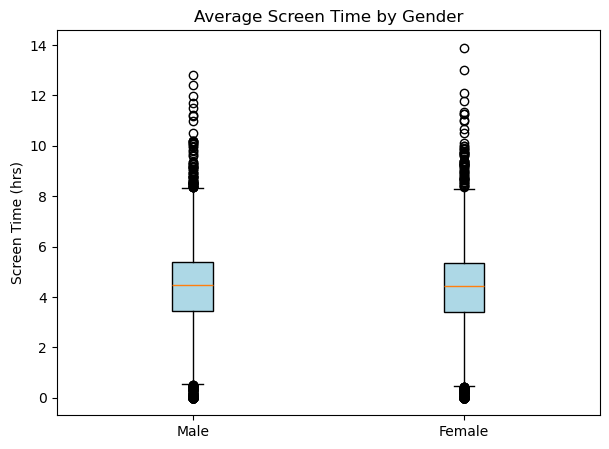

In [30]:
#Average Daily Screen Time by Gender
groups = [df[df["Gender"]=="Male"]["Avg_Daily_Screen_Time_hr"],
          df[df["Gender"]=="Female"]["Avg_Daily_Screen_Time_hr"]]
plt.figure(figsize=(7,5))
plt.boxplot(groups, labels=["Male","Female"], patch_artist=True,
            boxprops=dict(facecolor="lightblue"))
plt.title("Average Screen Time by Gender")
plt.ylabel("Screen Time (hrs)")
plt.show()

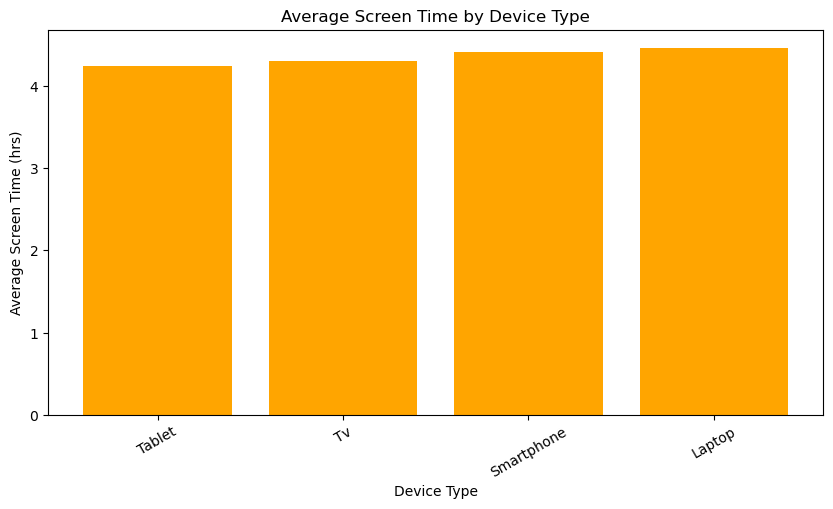

In [31]:
#Average Screen Time by Device Type
device_avg = df.groupby("Primary_Device")["Avg_Daily_Screen_Time_hr"].mean().sort_values()
plt.figure(figsize=(10,5))
plt.bar(device_avg.index, device_avg.values, color='orange')
plt.title("Average Screen Time by Device Type")
plt.xlabel("Device Type")
plt.ylabel("Average Screen Time (hrs)")
plt.xticks(rotation=30)
plt.show()

C:\Users\sidda\AppData\Local\Temp\ipykernel_13280\3710853696.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_avg = df.groupby("Age_Group")["Avg_Daily_Screen_Time_hr"].mean()


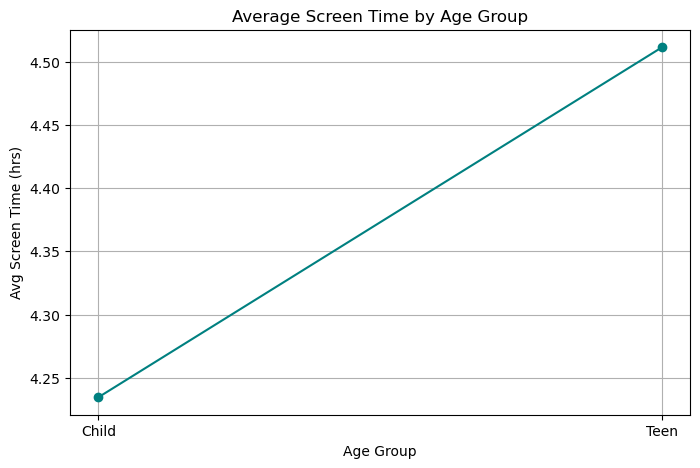

In [32]:
#Average Screen Time by Age Group
age_avg = df.groupby("Age_Group")["Avg_Daily_Screen_Time_hr"].mean()
plt.figure(figsize=(8,5))
plt.plot(age_avg.index, age_avg.values, marker='o', color='teal')
plt.title("Average Screen Time by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Avg Screen Time (hrs)")
plt.grid(True)
plt.show()

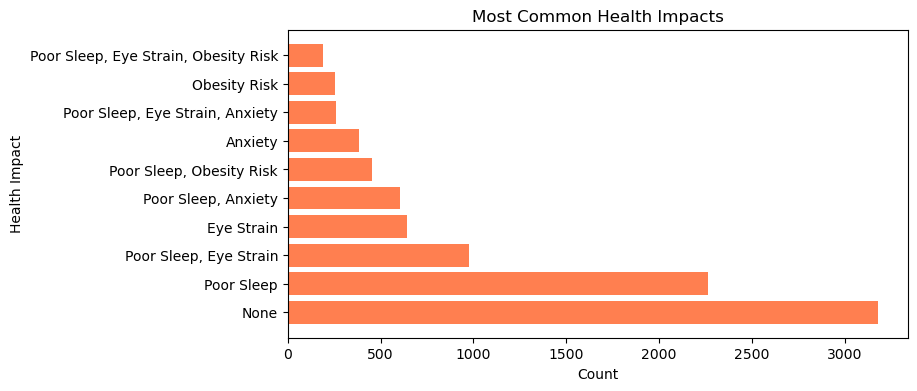

In [33]:
#Most Common Health Impacts
health_counts = df["Health_Impacts"].value_counts().head(10)
plt.figure(figsize=(8,4))
plt.barh(health_counts.index, health_counts.values, color='coral')
plt.title("Most Common Health Impacts")
plt.xlabel("Count")
plt.ylabel("Health Impact")
plt.show()

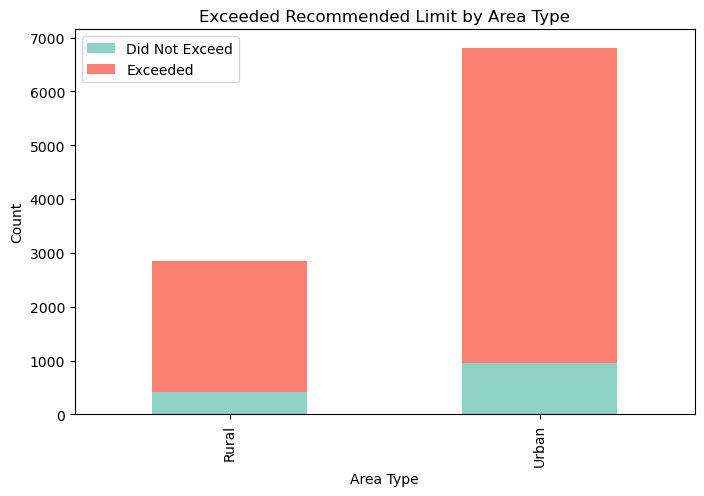

In [34]:
#Exceeded Limit (Yes/No) by Area Type
exceeded = df.groupby(["Urban_or_Rural","Exceeded_Recommended_Limit"]).size().unstack()
exceeded.plot(kind="bar", stacked=True, color=['#8dd3c7','#fb8072'], figsize=(8,5))
plt.title("Exceeded Recommended Limit by Area Type")
plt.xlabel("Area Type")
plt.ylabel("Count")
plt.legend(["Did Not Exceed", "Exceeded"])
plt.show()


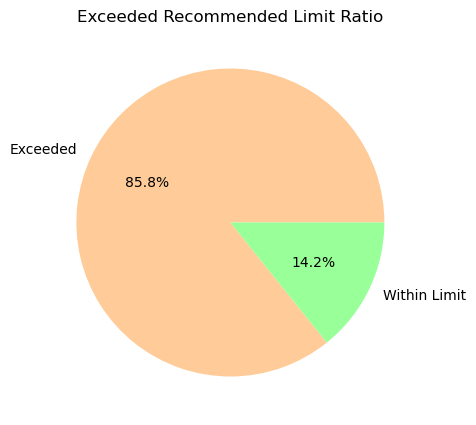

In [35]:
#% Exceeded Recommended Limit
plt.figure(figsize=(5,5))
plt.pie(df["Exceeded_Recommended_Limit"].value_counts(),
        labels=["Exceeded","Within Limit"], autopct="%1.1f%%", colors=["#ffcc99","#99ff99"])
plt.title("Exceeded Recommended Limit Ratio")
plt.show()

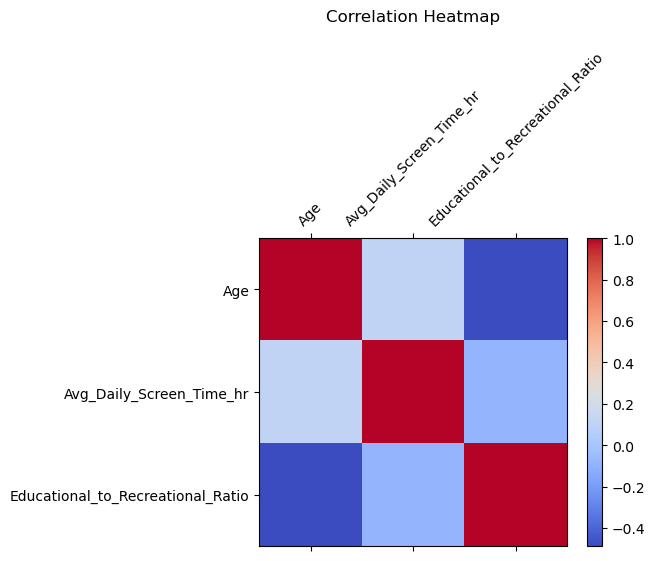

In [36]:
##Relationship & Correlation Visualizations
#Correlation Heatmap
corr = df[["Age","Avg_Daily_Screen_Time_hr","Educational_to_Recreational_Ratio"]].corr()
fig, ax = plt.subplots(figsize=(5,4))
cax = ax.matshow(corr, cmap="coolwarm")
plt.title("Correlation Heatmap", pad=20)
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45)
plt.yticks(range(len(corr.columns)), corr.columns)
fig.colorbar(cax)
plt.show()


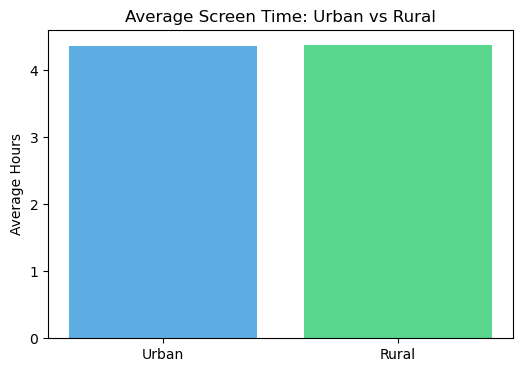

In [37]:
#Urban vs Rural Screen Time(Mean Screen TIme)
urban_avg = df[df["Urban_or_Rural"]=="Urban"]["Avg_Daily_Screen_Time_hr"].mean()
rural_avg = df[df["Urban_or_Rural"]=="Rural"]["Avg_Daily_Screen_Time_hr"].mean()

plt.figure(figsize=(6,4))
plt.bar(["Urban","Rural"], [urban_avg, rural_avg], color=["#5dade2","#58d68d"])
plt.title("Average Screen Time: Urban vs Rural")
plt.ylabel("Average Hours")
plt.show()

In [38]:
print("Insights Summary:")
print(f"- Average screen time: {df['Avg_Daily_Screen_Time_hr'].mean():.2f} hrs/day")
print(f"- % exceeding limit: {df['Exceeded_Recommended_Limit'].mean() * 100:.1f}%")
print(f"- Most used device: {df['Primary_Device'].mode()[0]}")
print(f"- Most common health issue: {df['Health_Impacts'].mode()[0]}")

Insights Summary:
- Average screen time: 4.37 hrs/day
- % exceeding limit: 85.8%
- Most used device: Smartphone
- Most common health issue: None


In [39]:
##Recommendation System

In [40]:
#Data Cleaning
#Helpful to remove the extra spaces and Case differences → "male", "MALE", "Male"
df["Gender"] = df["Gender"].str.strip().str.title()
df["Primary_Device"] = df["Primary_Device"].str.strip().str.title()
df["Urban_or_Rural"] = df["Urban_or_Rural"].str.strip().str.title()
df["Health_Impacts"] = df["Health_Impacts"].fillna("None") #this will fill it with none values

In [41]:
#pd.cut() divides the age range into bins (intervals) and we creating a new column Age Group #Here 8-12 -> Child and 12-18 Teen
df["Age_Group"] = pd.cut( df["Age"], bins=[8,12, 18], labels=["Child", "Teen"] )
df.head(10)

,Age,Gender,Avg_Daily_Screen_Time_hr,Primary_Device,Exceeded_Recommended_Limit,Educational_to_Recreational_Ratio,Health_Impacts,Urban_or_Rural,Age_Group
0,14,Male,3.99,Smartphone,True,0.42,"Poor Sleep, Eye Strain",Urban,Teen
1,11,Female,4.61,Laptop,True,0.30,Poor Sleep,Urban,Child
2,18,Female,3.73,Tv,True,0.32,Poor Sleep,Urban,Teen
3,15,Female,1.21,Laptop,False,0.39,None,Urban,Teen
4,12,Female,5.89,Smartphone,True,0.49,"Poor Sleep, Anxiety",Urban,Child
5,14,Female,4.88,Smartphone,True,0.44,Poor Sleep,Urban,Teen
6,17,Male,2.97,Tv,False,0.48,None,Rural,Teen
7,10,Male,2.74,Tv,True,0.54,None,Urban,Child
8,14,Male,4.61,Laptop,True,0.36,"Poor Sleep, Anxiety",Rural,Teen
9,18,Male,3.24,Tablet,True,0.48,"Poor Sleep, Obesity Risk",Urban,Teen


In [42]:
# Average screen time overall
avg = df["Avg_Daily_Screen_Time_hr"].mean()
print("Overall Average Screen Time:", round(avg, 2))

Overall Average Screen Time: 4.37


In [43]:
#how much time each age spends on screens on average
age_group_avg = df.groupby('Age')['Avg_Daily_Screen_Time_hr'].mean()
print(age_group_avg)

Age
8     4.034711
9     3.972046
10    3.912665
11    4.501541
12    4.554348
13    4.500967
14    4.514346
15    4.441725
16    4.551636
17    4.554989
18    4.502217
Name: Avg_Daily_Screen_Time_hr, dtype: float64


In [44]:
above_avg_age = age_group_avg[age_group_avg > avg] #Ages with Above-Average Screen Time
print("Ages above average screen time:\n", above_avg_age)

Ages above average screen time:
 Age
11    4.501541
12    4.554348
13    4.500967
14    4.514346
15    4.441725
16    4.551636
17    4.554989
18    4.502217
Name: Avg_Daily_Screen_Time_hr, dtype: float64


In [45]:
device_avg = df.groupby('Primary_Device')['Avg_Daily_Screen_Time_hr'].mean()
print(device_avg)

Primary_Device
Laptop        4.458784
Smartphone    4.410154
Tablet        4.241846
Tv            4.299544
Name: Avg_Daily_Screen_Time_hr, dtype: float64


In [46]:
above_avg_devices = device_avg[device_avg > avg]
print("Devices with Above Average Screen Time:\n", above_avg_devices)


Devices with Above Average Screen Time:
 Primary_Device
Laptop        4.458784
Smartphone    4.410154
Name: Avg_Daily_Screen_Time_hr, dtype: float64


In [47]:
gender_avg = df.groupby('Gender')['Avg_Daily_Screen_Time_hr'].mean()
print(gender_avg)

Gender
Female    4.348614
Male      4.386216
Name: Avg_Daily_Screen_Time_hr, dtype: float64


In [49]:
# Take inputs from user and .title() converts first charcater of each letter into Uppercase
age = int(input("Enter your Age: "))
gender = input("Enter your Gender (Male/Female): ").title()
device = input("Enter your Primary Device (e.x. Smartphone, Laptop): ").title()
screen_time = float(input("Enter your Average Daily Screen Time (in hours): "))
location = input("Enter your Location Type (Urban/Rural): ").title()

Enter your Age:  8
Enter your Gender (Male/Female):  Female
Enter your Primary Device (e.x. Smartphone, Laptop):  Laptop
Enter your Average Daily Screen Time (in hours):  4
Enter your Location Type (Urban/Rural):  Rural


In [50]:
def get_recommendation(age, gender, device, screen_time, location):
    insights = []
    # Compare with overall average
    if screen_time > avg:
        insights.append("Your screen time is higher than the overall average.")
    else:
        insights.append("Healthy range.")
    
    # Compare with age group
    if age in age_group_avg.index:
        if screen_time > age_group_avg[age]:
            insights.append(f"Your age people ({age}) spend around {round(age_group_avg[age],2)} hrs — you are above average.")
        else:
            insights.append(f"Less screen time than most people your age ({age}).")
    
    # Compare with gender group
    if gender in gender_avg.index:
        if screen_time > gender_avg[gender]:
            insights.append(f"{gender}s use {round(gender_avg[gender],2)} hrs/day — you exceed that.")
        else:
            insights.append(f"Your screen time is below the {gender} average.")
    
    # Device insights
    if device in device_avg.index:
        avg_dev_time = round(device_avg[device],2)
        if screen_time > avg_dev_time:
            insights.append(f"{device} users typically spend {avg_dev_time} hrs/day — you are above this.")
        else:
            insights.append(f"Your screen use on {device} is healthy compared to other users.")
    
    # Location-based tips
    if location == "Urban":
        insights.append("Urban users often face digital fatigue. Try digital detox breaks.")
    else:
        insights.append("Rural users benefit from using screen time for learning or creativity.")
    
    return "\n".join(insights)


In [51]:
result = get_recommendation(age, gender, device, screen_time, location)
print("Personalized Insights:\n")
print(result)


Personalized Insights:

Healthy range.
Less screen time than most people your age (8).
Your screen time is below the Female average.
Your screen use on Laptop is healthy compared to other users.
Rural users benefit from using screen time for learning or creativity.
